<a href="https://colab.research.google.com/github/Kieunhungtruong/Econometrics/blob/main/pythonversion/chapter3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="display:flex;flex-direction:column;align-items:center;justify-content:center;gap:10px;">
  <h1 style="text-align:center;font-size:26px;font-weight:bold;font-family:'Nunito';color:purple;">
    Chapter 3 – Phương sai thay đổi (Heteroskedasticity)
  </h1>
</div>

## Kết nối Google Drive và cài gói cần thiết

In [1]:
from google.colab import drive
drive.mount("/content/drive/", force_remount=True)

Mounted at /content/drive/


In [2]:
!pip install pyreadstat -q

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from scipy.stats import chi2
import pyreadstat
palette = ["#53b0ae", "#a31414", "#2b6999", "#e37000", "#b2c615", "#88837d", "#B3B3B3"]

## Đọc dữ liệu

In [3]:
df, meta = pyreadstat.read_dta(
    "/content/drive/MyDrive/econometrics/rawdata/migration_remittances_16_full.dta",
    encoding="latin1",
)
df.head()

,tinh,huyen,xa,diaban,hoso,num_migration,marital_status,HHsize,agehead,num_children0_5,...,durables_share,housing_share,others_share,healthcare_share,education_share,RedRiverDelta,Northmidlandareas,CentralCoast,Centralhighlands,MekongRiverDelta
0,1,1,4,8,14,NaN,0,2.0,63.0,0.0,...,0.000000,0.030590,0.021175,0.004854,0.044689,1.0,0.0,0.0,0.0,0.0
1,1,1,4,8,15,NaN,1,5.0,37.0,0.0,...,0.026955,0.011273,0.006304,0.000797,0.006511,1.0,0.0,0.0,0.0,0.0
2,1,1,4,8,19,NaN,1,2.0,61.0,0.0,...,0.000000,0.027630,0.013743,0.014355,0.000000,1.0,0.0,0.0,0.0,0.0
3,1,1,7,6,13,NaN,1,3.0,62.0,0.0,...,0.018952,0.022694,0.014611,0.002366,0.056978,1.0,0.0,0.0,0.0,0.0
4,1,1,7,6,14,NaN,1,5.0,62.0,0.0,...,0.000000,0.067794,0.004254,0.011658,0.002564,1.0,0.0,0.0,0.0,0.0


---
# 3.1 Phương sai thay đổi là gì?

Khi có phương sai thay đổi, ước lượng OLS vẫn **không lệch** nhưng **không còn là BLUE** vì sai số chuẩn được tính sai, kéo theo thống kê t, p-value và khoảng tin cậy đều không chính xác.

---
# 3.2 Cách phát hiện phương sai thay đổi

## Bước 1 – Hồi quy OLS gốc và lấy phần dư

In [4]:
X = sm.add_constant(df["remittances"])
model = sm.OLS(df["per_expenditure"], X).fit()
print(model.summary())

df["residuals"]         = model.resid
df["squared_residuals"] = df["residuals"] ** 2
df["yhat"]              = model.fittedvalues
df["yhat2"]             = df["yhat"] ** 2

                            OLS Regression Results                            
Dep. Variable:        per_expenditure   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     177.8
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           3.31e-40
Time:                        10:32:42   Log-Likelihood:            -1.0757e+05
No. Observations:                9399   AIC:                         2.152e+05
Df Residuals:                    9397   BIC:                         2.152e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        2.556e+04    246.728    103.613      

## Phương pháp không chính thức – Đồ thị phần dư (Hình 3.2)

Vẽ phần dư theo biến độc lập để quan sát trực quan xem phần dư có dao động có hệ thống theo biến độc lập không.

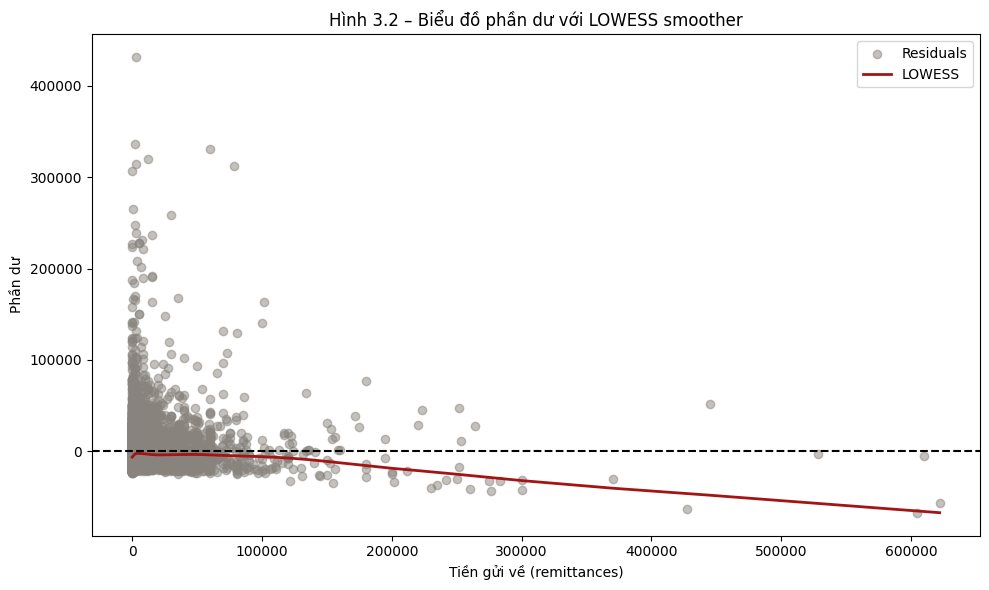

In [5]:
lowess_result = lowess(df["residuals"], df["remittances"])

plt.figure(figsize=(10, 6))
plt.scatter(df["remittances"], df["residuals"],
            color=palette[5], alpha=0.5, label="Residuals")
plt.plot(lowess_result[:, 0], lowess_result[:, 1],
         color=palette[1], linewidth=2, label="LOWESS")
plt.axhline(y=0, color="black", linestyle="--")
plt.xlabel("Tiền gửi về (remittances)")
plt.ylabel("Phần dư")
plt.title("Hình 3.2 – Biểu đồ phần dư với LOWESS smoother")
plt.legend()
plt.tight_layout()
plt.show()

## Kiểm định Breusch–Pagan (Bảng 3.1)

**Các bước:**
1. Hồi quy OLS gốc (đã làm ở trên)
2. Lấy phần dư $\hat{\varepsilon}$ và bình phương $\hat{\varepsilon}^2$
3. Hồi quy $\hat{\varepsilon}^2$ với tất cả các biến độc lập $x_i$
4. Kiểm định F cho mức ý nghĩa chung

Nếu p-value < 0.05 → bác bỏ H₀ (phương sai không đổi) → mô hình có phương sai thay đổi.

In [6]:
# Bước 3 – Hồi quy e² ~ remittances
X_rsq    = sm.add_constant(df["remittances"])
model_bp = sm.OLS(df["squared_residuals"], X_rsq).fit()
print(model_bp.summary())

# Thống kê LM = n * R²
n       = len(df)
LM_bp   = n * model_bp.rsquared
p_bp    = 1 - chi2.cdf(LM_bp, df=1)
print(f"LM statistic : {LM_bp:.4f}")
print(f"P-value      : {p_bp:.6f}")

                            OLS Regression Results                            
Dep. Variable:      squared_residuals   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     11.37
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           0.000748
Time:                        10:32:44   Log-Likelihood:            -2.2140e+05
No. Observations:                9399   AIC:                         4.428e+05
Df Residuals:                    9397   BIC:                         4.428e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        4.623e+08   4.48e+07     10.314      

### Kiểm định Breusch–Pagan bằng hàm có sẵn

In [7]:
bp_test  = het_breuschpagan(df["residuals"], X)
bp_names = ["LM Statistic", "LM p-value", "F Statistic", "F p-value"]
for name, val in zip(bp_names, bp_test):
    print(f"  {name}: {val:.6f}")
# p-value ≈ 0.0007 < 0.05  →  mô hình có phương sai thay đổi

  LM Statistic: 11.362817
  LM p-value: 0.000749
  F Statistic: 11.374150
  F p-value: 0.000748


## Kiểm định White thông thường (Bảng 3.2)

Hồi quy $\hat{\varepsilon}^2$ với $x_i$, $x_i^2$ và tích các biến độc lập.
Thống kê: $LM = n \times R^2 \sim \chi^2(k)$ với $k$ là số biến phụ trợ.

In [8]:
# Thủ công
df["remittances_sq"] = df["remittances"] ** 2
X_white    = sm.add_constant(df[["remittances", "remittances_sq"]])
model_wt   = sm.OLS(df["squared_residuals"], X_white).fit()
print(model_wt.summary())
print(f"LM White = {n * model_wt.rsquared:.4f}")

                            OLS Regression Results                            
Dep. Variable:      squared_residuals   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     7.093
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           0.000835
Time:                        10:32:44   Log-Likelihood:            -2.2139e+05
No. Observations:                9399   AIC:                         4.428e+05
Df Residuals:                    9396   BIC:                         4.428e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           4.387e+08    4.7e+07      9.

In [9]:
# Hàm có sẵn
white_test = het_white(model.resid, model.model.exog)
for name, val in zip(bp_names, white_test):
    print(f"  {name}: {val:.6f}")
# LM ≈ 14.17, chi2(2), p ≈ 0.0008  →  phương sai thay đổi

  LM Statistic: 14.168901
  LM p-value: 0.000838
  F Statistic: 7.092882
  F p-value: 0.000835


## Kiểm định White có điều chỉnh (Bảng 3.3)

Thay vì dùng $x_i$ và $x_i^2$, hồi quy $\hat{\varepsilon}^2$ với $\hat{y}$ và $\hat{y}^2$.
Phù hợp khi mô hình có nhiều biến độc lập (tiết kiệm bậc tự do).

$$\hat{\varepsilon}^2_i = \delta_0 + \delta_1\hat{y}_i + \delta_2\hat{y}^2_i + u_i$$

In [10]:
X_wadj    = sm.add_constant(df[["yhat", "yhat2"]])
model_wadj = sm.OLS(df["squared_residuals"], X_wadj).fit()
print(model_wadj.summary())
print(f"LM White (adjusted) = {n * model_wadj.rsquared:.4f}")
# LM ≈ 14.17, chi2(2), p ≈ 0.0008  →  phương sai thay đổi

                            OLS Regression Results                            
Dep. Variable:      squared_residuals   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     7.093
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           0.000835
Time:                        10:32:44   Log-Likelihood:            -2.2139e+05
No. Observations:                9399   AIC:                         4.428e+05
Df Residuals:                    9396   BIC:                         4.428e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.061e+09   8.84e+08     -2.332      0.0

---
# 3.3 Cách xử lý mô hình khi có phương sai thay đổi

## 1. WLS khi $\text{Var}(\varepsilon) \propto x_i^2$ (Bảng 3.4)

Chia cả hai vế phương trình hồi quy cho $x_i$ (remittances), sau đó hồi quy OLS không chặn trên dữ liệu đã chuẩn hoá.

> Cách chuẩn nhất là dùng `sm.WLS` với `weights = 1/remittances²`.

In [11]:
df2 = df[df["remittances"] > 0].copy()

# Step 1 OLS
X = sm.add_constant(df2["remittances"])
y = df2["per_expenditure"]
ols = sm.OLS(y, X).fit()

# Step 2 |res|
abs_res = np.abs(ols.resid)

# Step 3 weighting equation WITHOUT constant
Z = df2[["remittances"]]   # KHÔNG add_constant
var_model = sm.OLS(abs_res, Z).fit()

sigma_hat = var_model.fittedvalues

# Step 4 weights
w = 1 / (sigma_hat**2)

# Step 5 WLS
wls = sm.WLS(y, X, weights=w).fit()
print(wls.summary())

# Step 6 weighted residuals
wgt_res = wls.resid * np.sqrt(w)

# Step 7 BP test
aux = sm.OLS(wgt_res**2, sm.add_constant(df2["remittances"])).fit()

print(f"F = {aux.fvalue:.2f}, p = {aux.f_pvalue:.4f}")

                            WLS Regression Results                            
Dep. Variable:        per_expenditure   R-squared:                       0.000
Model:                            WLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     3.129
Date:                Wed, 08 Apr 2026   Prob (F-statistic):             0.0770
Time:                        10:32:44   Log-Likelihood:            -1.1032e+05
No. Observations:                7953   AIC:                         2.206e+05
Df Residuals:                    7951   BIC:                         2.207e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        2.484e+04    260.110     95.497      



```
Note: kết quả bp test sau wls có thể khác stata do cách tính residual và weight nội bộ.
Chênh lệch không ảnh hưởng kết luận: mô hình sau wls không còn heteroskedasticity.
```



## 2. WLS khi $\text{Var}(\varepsilon) \propto x_i$ (Bảng 3.5)

Chia cả hai vế cho $\sqrt{x_i}$, dùng `weights = 1/remittances`.

In [12]:
df4 = df[df["remittances"] > 0].copy()
X4  = sm.add_constant(df4["remittances"])
y4  = df4["per_expenditure"]

# WLS với trọng số 1/remittances
w = 1 / df4["remittances"]
model_wls2 = sm.WLS(y4, X4, weights=w).fit()
print(model_wls2.summary())

# weighted residual giống phần trên
wgt_res2 = model_wls2.resid * np.sqrt(w)

# BP test thủ công
aux2 = sm.OLS(wgt_res2**2, sm.add_constant(df4["remittances"])).fit()

print(f"F = {aux2.fvalue:.2f}, p = {aux2.f_pvalue:.4f}")
# p > 0.05 → đã xử lý xong phương sai thay đổi

                            WLS Regression Results                            
Dep. Variable:        per_expenditure   R-squared:                       0.002
Model:                            WLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     12.73
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           0.000362
Time:                        10:32:44   Log-Likelihood:                -96022.
No. Observations:                7953   AIC:                         1.920e+05
Df Residuals:                    7951   BIC:                         1.921e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        2.341e+04    232.068    100.878      

## 3. Lấy log (cách kinh nghiệm)

Log nén tỷ lệ đo lường của biến, giúp giảm phương sai thay đổi. Tuy nhiên không đảm bảo loại bỏ hoàn toàn.

In [13]:
df5 = df[(df["remittances"] > 0) & (df["per_expenditure"] > 0)].copy()
df5["ln_remittances"]     = np.log(df5["remittances"])
df5["ln_per_expenditure"] = np.log(df5["per_expenditure"])

X5        = sm.add_constant(df5["ln_remittances"])
model_log = sm.OLS(df5["ln_per_expenditure"], X5).fit()
print(model_log.summary())

bp_log = het_breuschpagan(model_log.resid, model_log.model.exog)
print(f"BP F = {bp_log[2]:.4f}, p = {bp_log[3]:.6f}")
# F ≈ 15.89, p ≈ 0.0001  →  vẫn còn phương sai thay đổi

                            OLS Regression Results                            
Dep. Variable:     ln_per_expenditure   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     478.7
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          4.40e-103
Time:                        10:32:44   Log-Likelihood:                -7210.2
No. Observations:                7953   AIC:                         1.442e+04
Df Residuals:                    7951   BIC:                         1.444e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              9.3161      0.032    294.

## 4. WLS với trọng số là giá trị dự báo $\hat{y}^2$ (Bảng 3.7)

Khi không biết nguồn gốc của phương sai thay đổi, dùng `weights = 1/ŷ²` là cách thực hành phổ biến.

In [14]:
# yhat và yhat2 đã được tạo ở Phần 2
df_valid = df[df["yhat2"] > 0].copy()
X_v  = sm.add_constant(df_valid["remittances"])
y_v  = df_valid["per_expenditure"]

model_wls3 = sm.WLS(y_v, X_v, weights=1 / df_valid["yhat2"]).fit()
print(model_wls3.summary())
# _cons ≈ 25,114 ; remittances ≈ 0.187 (p=0.000)

bp3 = het_breuschpagan(model_wls3.resid, model_wls3.model.exog)
print(f"BP F = {bp3[2]:.2f}, p = {bp3[3]:.4f}")
# F ≈ 10.25, p = 0.0014  →  vẫn còn phương sai thay đổi

                            WLS Regression Results                            
Dep. Variable:        per_expenditure   R-squared:                       0.014
Model:                            WLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     131.0
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           3.85e-30
Time:                        10:32:44   Log-Likelihood:            -1.0743e+05
No. Observations:                9399   AIC:                         2.149e+05
Df Residuals:                    9397   BIC:                         2.149e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        2.511e+04    248.091    101.229      

## 5. Sai số chuẩn mạnh – Robust Standard Errors (Bảng 3.8)

Cách đơn giản và phổ biến nhất: giữ nguyên OLS nhưng dùng **HC1 robust SE** (tương đương `robust` trong Stata). Hệ số không thay đổi, chỉ sai số chuẩn thay đổi.

In [15]:
# Ví dụ 1: per_expenditure ~ remittances (Bảng 3.8)
X = sm.add_constant(df["remittances"])
model_r1 = sm.OLS(df["per_expenditure"], X).fit(cov_type="HC1")
print(model_r1.summary())
# remittances coef ≈ 0.128, Robust SE ≈ 0.0162  (Stata: 0.128, 0.0162)

                            OLS Regression Results                            
Dep. Variable:        per_expenditure   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     62.33
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           3.24e-15
Time:                        10:32:44   Log-Likelihood:            -1.0757e+05
No. Observations:                9399   AIC:                         2.152e+05
Df Residuals:                    9397   BIC:                         2.152e+05
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const        2.556e+04    249.712    102.375      

### Ví dụ 2: food_share ~ nhiều biến (Bảng 3.9)

So sánh OLS thường và Robust SE khi mô hình có nhiều biến độc lập.

In [16]:
xvars = [
    "ln_expenditure", "agehead", "agehead2", "primary", "secondary",
    "high_school", "higher_education", "HHsize", "HHsize2",
    "dependency_ratio", "domestic_remittances", "overseas_remittances",
    "urban", "RedRiverDelta", "Northmidlandareas", "MekongRiverDelta",
    "Centralhighlands", "CentralCoast",
]
df["agehead2"] = df["agehead"] ** 2
df["HHsize2"]  = df["HHsize"]  ** 2

df_fs = df.dropna(subset=["food_share"] + xvars).copy()
X_fs  = sm.add_constant(df_fs[xvars])
y_fs  = df_fs["food_share"]

model_ols_fs = sm.OLS(y_fs, X_fs).fit()
model_rob_fs = sm.OLS(y_fs, X_fs).fit(cov_type="HC1")

print("=== OLS ===")
print(model_ols_fs.summary())
print("\n=== Robust SE ===")
print(model_rob_fs.summary())

# Kiểm định BP & White
bp_fs    = het_breuschpagan(model_ols_fs.resid, model_ols_fs.model.exog)
white_fs = het_white(model_ols_fs.resid, model_ols_fs.model.exog)
print(f"BP  F = {bp_fs[2]:.2f},    p = {bp_fs[3]:.2e}")
print(f"White LM = {white_fs[0]:.2f}, p = {white_fs[1]:.2e}")

=== OLS ===
                            OLS Regression Results                            
Dep. Variable:             food_share   R-squared:                       0.691
Model:                            OLS   Adj. R-squared:                  0.691
Method:                 Least Squares   F-statistic:                     1041.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:32:44   Log-Likelihood:                 13344.
No. Observations:                8381   AIC:                        -2.665e+04
Df Residuals:                    8362   BIC:                        -2.652e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const               

### Ví dụ 3: wage ~ urban + gender + yearsofedu + yearsofexperience (Bảng 3.10–3.11)

In [17]:
df_wage, _ = pyreadstat.read_dta(
    "/content/drive/MyDrive/econometrics/rawdata/wage2020.dta",
    encoding="latin1",
)

wage_vars  = ["urban", "gender", "yearsofedu", "yearsofexperience"]
X_w = sm.add_constant(df_wage[wage_vars])
y_w = df_wage["wage"]

model_ols_w = sm.OLS(y_w, X_w).fit()
model_rob_w = sm.OLS(y_w, X_w).fit(cov_type="HC1")

print("=== OLS (Bảng 3.10) ===")
print(model_ols_w.summary())
print("\n=== Robust SE (Bảng 3.11) ===")
print(model_rob_w.summary())

bp_w    = het_breuschpagan(model_ols_w.resid, model_ols_w.model.exog)
white_w = het_white(model_ols_w.resid, model_ols_w.model.exog)
print(f"BP  F = {bp_w[2]:.2f},   p = {bp_w[3]:.2e}")
print(f"White LM = {white_w[0]:.2f}, p = {white_w[1]:.2e}")

=== OLS (Bảng 3.10) ===
                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.200
Model:                            OLS   Adj. R-squared:                  0.200
Method:                 Least Squares   F-statistic:                     633.0
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:32:47   Log-Likelihood:            -1.2341e+05
No. Observations:               10118   AIC:                         2.468e+05
Df Residuals:                   10113   BIC:                         2.469e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const         

Lưu ý:
1. sử dụng pyreadstat thay vì pandas.read_stata() vì đọc file .dta nhanh hơn, giữ được label và metadata đầy đủ.
2. pandas.read_stata() thực chất cũng dùng pyreadstat phía sau.
3. Một số kiểm định khác biệt nhẹ so với stata do khác cách triển khai các gói thống kê.

<h2 style="font-size: 26px; font-weight: bold; font-family:'Nunito'; color: purple;">About the Authors:</h2>

<a href="https://www.linkedin.com/in/truongnhung2002"> Nhung Truong (Kristen Zhang) </a> has a degree in Investment Economics from UEH, with a focus on quantitative research.

### <h3 align="center"> © 2026 Nhung Truong. Licensed under CC BY 4.0 </h3>: